# Task 1 - Exploratory Data Analysis (EDA)

### Objective
Understand the connected-facilities telemetry and identify patterns relevant to asset health, failures, energy consumption, and operational efficiency.

### Challenge requirements covered
1. Understand data distributions
2. Identify missing values and anomalies
3. Discover temporal patterns
4. Analyze asset behavior across sites
5. Compare performance across asset types
6. Identify factors influencing equipment failures
7. Identify factors affecting energy consumption

### Deliverables
- Visualizations
- Statistical summaries
- Key observations
- Business insights

In [2]:
# ============================================================
# 01. SETUP
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")

DATA_DIR = "../data/raw"
OUTPUT_DIR = "../outputs/eda"
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

print("EDA environment initialized")

EDA environment initialized


## 1. Load and Understand the Datasets

The analysis uses three related datasets:

- **Sensor Telemetry:** time-series measurements from connected assets
- **Asset Metadata:** asset identity, type, capacity, installation date, and hierarchy
- **Asset Connectivity:** relationships between assets

In [3]:
telemetry = pd.read_csv(os.path.join(DATA_DIR, "sensor_telemetry.csv"), parse_dates=["timestamp"])
metadata = pd.read_csv(os.path.join(DATA_DIR, "asset_metadata.csv"), parse_dates=["installation_date"])
connectivity = pd.read_csv(os.path.join(DATA_DIR, "asset_connectivity.csv"))

print("Telemetry:", telemetry.shape)
print("Metadata:", metadata.shape)
print("Connectivity:", connectivity.shape)

display(telemetry.head())
display(metadata.head())
display(connectivity.head())

Telemetry: (259200, 12)
Metadata: (30, 9)
Connectivity: (36, 4)


,timestamp,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,operating_mode,fault_flag
0,2026-01-01 00:00:00,SITE_01,BLDG_01,ASSET_001,18.621,54.498,1.521,0.222,8.971,31,Idle,0
1,2026-01-01 00:15:00,SITE_01,BLDG_01,ASSET_001,19.923,47.778,1.505,0.191,8.939,43,Idle,0
2,2026-01-01 00:30:00,SITE_01,BLDG_01,ASSET_001,19.225,53.328,1.386,0.150,7.824,35,Idle,0
3,2026-01-01 00:45:00,SITE_01,BLDG_01,ASSET_001,19.856,56.998,1.528,0.206,54.215,40,Cooling,0
4,2026-01-01 01:00:00,SITE_01,BLDG_01,ASSET_001,19.841,54.713,1.549,0.181,43.278,25,Cooling,0


,asset_id,site_id,building_id,asset_name,asset_type,manufacturer,installation_date,capacity,parent_asset_id
0,ASSET_001,SITE_01,BLDG_01,Chiller-01,Chiller,Carrier,2022-07-18,1000,NaN
1,ASSET_002,SITE_01,BLDG_01,AHU-01-1,AHU,Daikin,2023-06-27,200,ASSET_001
2,ASSET_003,SITE_01,BLDG_01,AHU-01-2,AHU,Trane,2022-05-23,150,ASSET_001
3,ASSET_004,SITE_01,BLDG_01,Pump-01,Pump,KSB,2024-11-05,100,ASSET_001
4,ASSET_005,SITE_01,BLDG_01,EnergyMeter-01,Energy Meter,ABB,2023-08-13,500,NaN


,source_asset_id,target_asset_id,connection_type,relationship_strength
0,ASSET_001,ASSET_002,Supplies,0.890
1,ASSET_001,ASSET_002,Controls,0.680
2,ASSET_001,ASSET_003,Supplies,0.820
3,ASSET_001,ASSET_003,Controls,0.650
4,ASSET_004,ASSET_001,Supplies,0.700


## 2. Dataset Overview and Statistical Summary

Establish the baseline structure, data types, numerical ranges, and categorical distributions before deeper analysis.

In [4]:
print("--- TELEMETRY SCHEMA ---")
telemetry.info()
print("\n--- METADATA SCHEMA ---")
metadata.info()
print("\n--- CONNECTIVITY SCHEMA ---")
connectivity.info()

numeric_cols = ["temperature", "humidity", "pressure", "vibration", "power_consumption", "occupancy_count"]

print("\n--- STATISTICAL SUMMARY ---")
display(telemetry[numeric_cols].describe().T)

print("\n--- CATEGORICAL SUMMARY ---")
for col in ["site_id", "building_id", "operating_mode", "fault_flag"]:
    print(f"\n{col}")
    display(telemetry[col].value_counts().to_frame("count"))

--- TELEMETRY SCHEMA ---
<class 'pandas.DataFrame'>
RangeIndex: 259200 entries, 0 to 259199
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   timestamp          259200 non-null  datetime64[us]
 1   site_id            259200 non-null  str           
 2   building_id        259200 non-null  str           
 3   asset_id           259200 non-null  str           
 4   temperature        256649 non-null  float64       
 5   humidity           256535 non-null  float64       
 6   pressure           257200 non-null  float64       
 7   vibration          257157 non-null  float64       
 8   power_consumption  259200 non-null  float64       
 9   occupancy_count    259200 non-null  int64         
 10  operating_mode     259200 non-null  str           
 11  fault_flag         259200 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(2), str(4)
memory usage: 23.7 MB

--- METADATA

,count,mean,std,min,25%,50%,75%,max
temperature,"256,649.000",22.514,2.384,16.301,20.585,22.508,24.460,30.154
humidity,"256,535.000",51.757,5.545,32.388,47.569,51.549,55.922,72.895
pressure,"257,200.000",1.800,1.370,0.496,0.979,1.096,1.555,5.531
vibration,"257,157.000",0.135,0.081,0.000,0.076,0.100,0.190,1.803
power_consumption,"259,200.000",29.313,29.103,0.250,10.377,15.056,35.459,334.276
occupancy_count,"259,200.000",67.781,60.412,0.000,24.000,34.000,128.000,256.000



--- CATEGORICAL SUMMARY ---

site_id


,count
site_id,
SITE_01,86400
SITE_02,86400
SITE_03,86400



building_id


,count
building_id,
BLDG_01,43200
BLDG_02,43200
BLDG_03,43200
BLDG_04,43200
BLDG_05,43200
BLDG_06,43200



operating_mode


,count
operating_mode,
Cooling,134753
Idle,118730
Heating,5717



fault_flag


,count
fault_flag,
0,258930
1,270


## 3. Data Quality — Missing Values, Anomalies and Integrity

Check whether the IoT stream is reliable for downstream analysis. An unusual observation is not automatically treated as bad data because it may represent a real operational event or degradation signal.

In [5]:
# Missing values
missing_summary = pd.DataFrame({
    "missing_count": telemetry.isna().sum(),
    "missing_percentage": telemetry.isna().mean() * 100
}).sort_values("missing_percentage", ascending=False)
display(missing_summary)

# Duplicates and invalid values
quality_checks = {
    "Duplicate telemetry rows": telemetry.duplicated().sum(),
    "Duplicate timestamp + asset": telemetry.duplicated(["timestamp", "asset_id"]).sum(),
    "Negative vibration": (telemetry["vibration"] < 0).sum(),
    "Negative power": (telemetry["power_consumption"] < 0).sum(),
    "Negative occupancy": (telemetry["occupancy_count"] < 0).sum(),
    "Humidity outside 0-100": ((telemetry["humidity"] < 0) | (telemetry["humidity"] > 100)).sum(),
    "Invalid fault flag": (~telemetry["fault_flag"].isin([0, 1])).sum(),
    "Duplicate connectivity relationship": connectivity.duplicated(["source_asset_id", "target_asset_id", "connection_type"]).sum(),
    "Connectivity self-loops": (connectivity["source_asset_id"] == connectivity["target_asset_id"]).sum()
}
display(pd.Series(quality_checks, name="count"))

,missing_count,missing_percentage
humidity,2665,1.028
temperature,2551,0.984
vibration,2043,0.788
pressure,2000,0.772
asset_id,0,0.000
building_id,0,0.000
site_id,0,0.000
timestamp,0,0.000
power_consumption,0,0.000
occupancy_count,0,0.000


Duplicate telemetry rows               0
Duplicate timestamp + asset            0
Negative vibration                     0
Negative power                         0
Negative occupancy                     0
Humidity outside 0-100                 0
Invalid fault flag                     0
Duplicate connectivity relationship    0
Connectivity self-loops                0
Name: count, dtype: int64

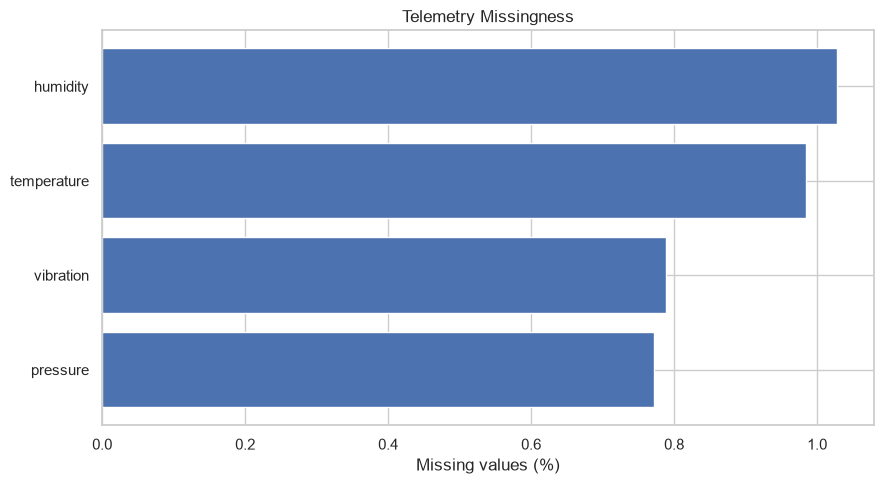

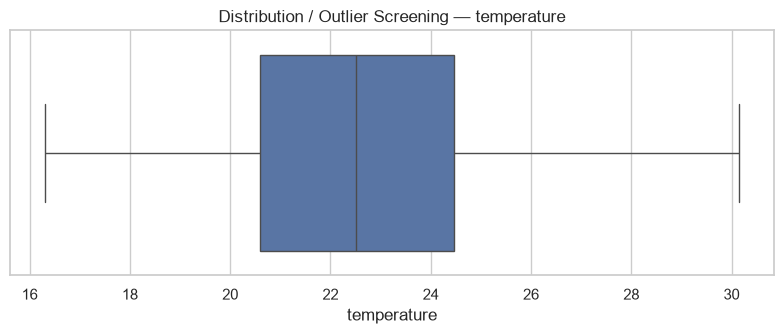

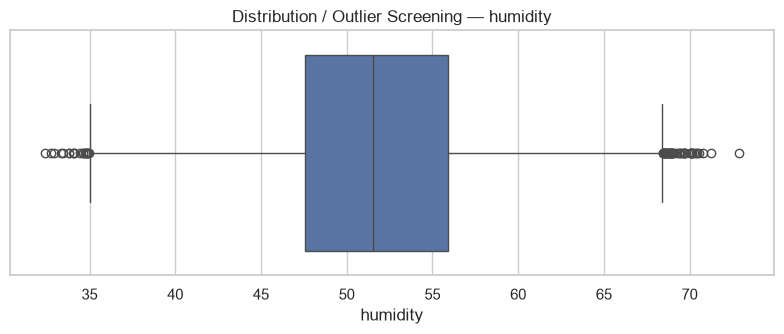

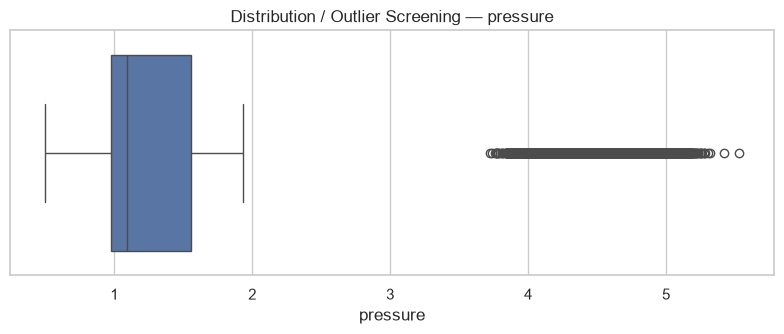

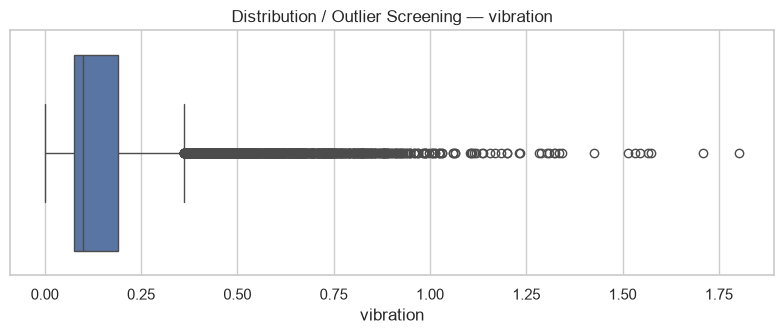

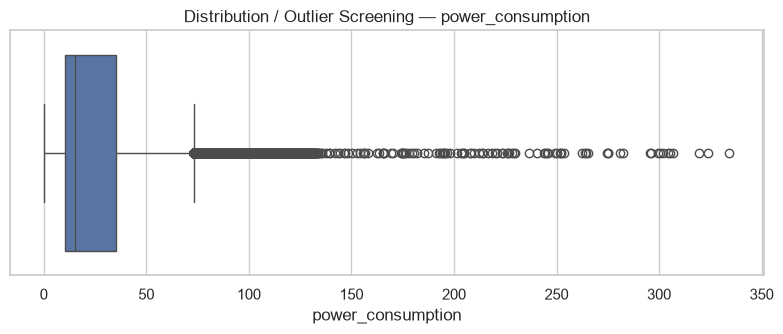

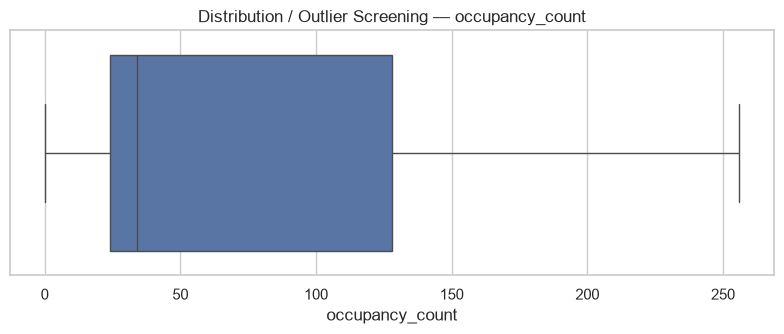

In [6]:
# Missing-value visualization
plot_missing = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_percentage")
plt.figure(figsize=(9, 5))
plt.barh(plot_missing.index, plot_missing["missing_percentage"])
plt.xlabel("Missing values (%)")
plt.title("Telemetry Missingness")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "missing_values.png"), dpi=150)
plt.show()

# Outlier screening
for col in numeric_cols:
    plt.figure(figsize=(8, 3.5))
    sns.boxplot(x=telemetry[col])
    plt.title(f"Distribution / Outlier Screening — {col}")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, f"boxplot_{col}.png"), dpi=150)
    plt.show()

## 4. Temporal Patterns

Analyze how facility operations change across **hour of day, day of week, weekday/weekend, operating hours, and daily trends**. These patterns are important for understanding normal energy demand and operating behavior.

In [7]:
eda_df = telemetry.merge(
    metadata[["asset_id", "asset_type", "manufacturer", "installation_date", "capacity", "parent_asset_id"]],
    on="asset_id", how="left"
)

eda_df["hour"] = eda_df["timestamp"].dt.hour
eda_df["day_of_week"] = eda_df["timestamp"].dt.day_name()
eda_df["day_num"] = eda_df["timestamp"].dt.dayofweek
eda_df["date"] = eda_df["timestamp"].dt.date
eda_df["is_weekend"] = eda_df["day_num"] >= 5
eda_df["is_business_hour"] = eda_df["hour"].between(8, 17)

# Sampling validation
time_diff = (
    telemetry[["asset_id", "timestamp"]]
    .sort_values(["asset_id", "timestamp"])
    .groupby("asset_id")["timestamp"].diff()
)
print("Start:", telemetry["timestamp"].min())
print("End:", telemetry["timestamp"].max())
print("Unique timestamps:", telemetry["timestamp"].nunique())
print("Non-15-minute intervals:", (time_diff.dropna() != pd.Timedelta(minutes=15)).sum())

Start: 2026-01-01 00:00:00
End: 2026-03-31 23:45:00
Unique timestamps: 8640
Non-15-minute intervals: 0


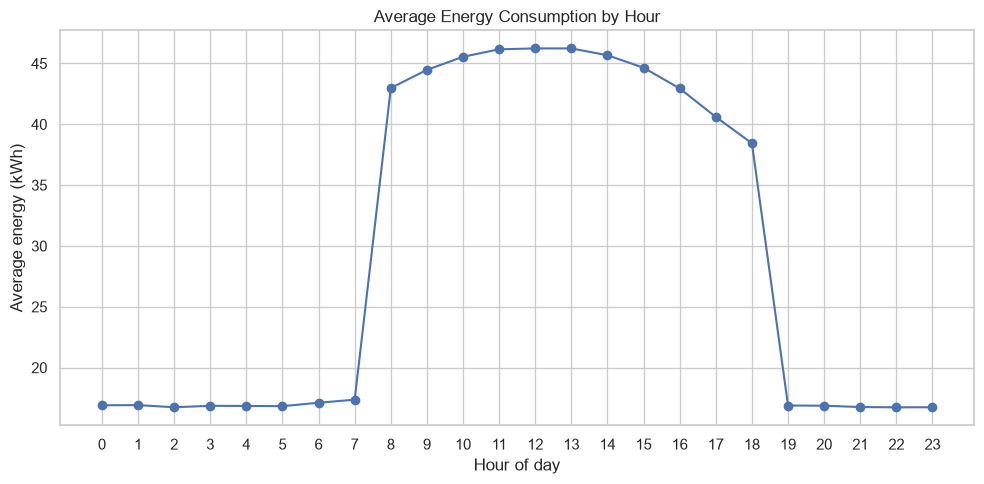

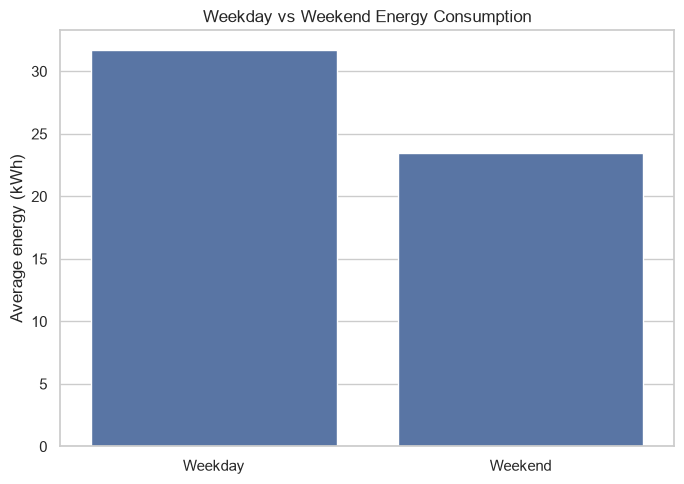

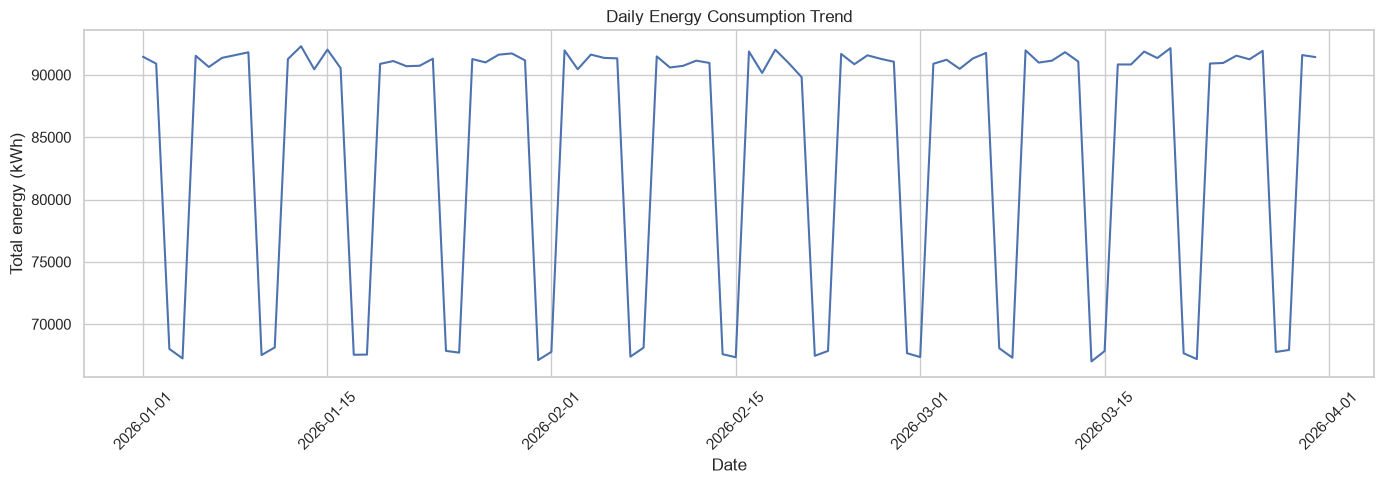

In [8]:
# Hourly energy
hourly_energy = eda_df.groupby("hour")["power_consumption"].mean()
plt.figure(figsize=(10, 5))
plt.plot(hourly_energy.index, hourly_energy.values, marker="o")
plt.xticks(range(24))
plt.xlabel("Hour of day")
plt.ylabel("Average energy (kWh)")
plt.title("Average Energy Consumption by Hour")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "hourly_energy.png"), dpi=150)
plt.show()

# Weekday vs weekend
weekend_energy = eda_df.groupby("is_weekend")["power_consumption"].mean()
weekend_labels = ["Weekday", "Weekend"]
plt.figure(figsize=(7, 5))
sns.barplot(x=weekend_labels, y=weekend_energy.reindex([False, True]).values)
plt.ylabel("Average energy (kWh)")
plt.title("Weekday vs Weekend Energy Consumption")
plt.tight_layout()
plt.show()

# Daily trend
daily_energy = eda_df.groupby("date")["power_consumption"].sum()
plt.figure(figsize=(14, 5))
plt.plot(pd.to_datetime(daily_energy.index), daily_energy.values)
plt.xlabel("Date")
plt.ylabel("Total energy (kWh)")
plt.title("Daily Energy Consumption Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "daily_energy_trend.png"), dpi=150)
plt.show()

## 5. Asset Behavior Across Sites

Compare operational behavior across sites and buildings using energy, sensor health indicators, and fault activity. The purpose is to identify differences in operating conditions and potential performance gaps.

,avg_power,total_energy,avg_vibration,avg_pressure,fault_rate
site_id,,,,,
SITE_02,29.712,"2,567,110.143",0.136,1.800,0.001
SITE_01,29.458,"2,545,178.546",0.133,1.800,0.001
SITE_03,28.768,"2,485,537.741",0.135,1.800,0.001


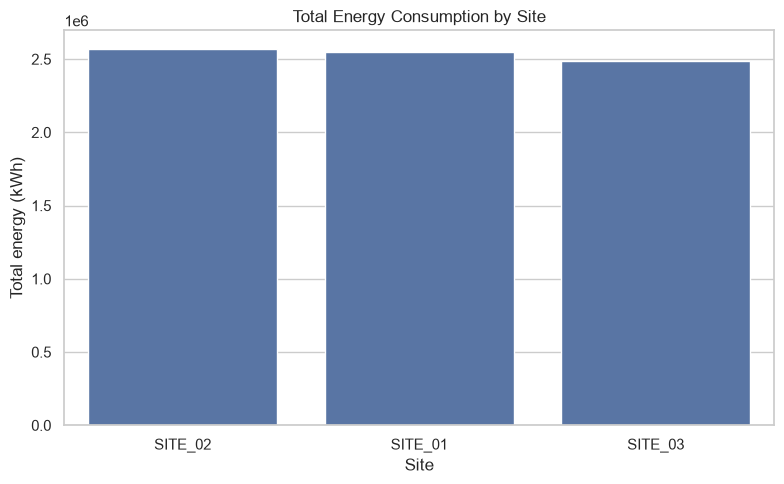

,avg_power,total_energy,fault_rate
building_id,,,
BLDG_02,29.860,"1,289,968.912",0.001
BLDG_04,29.765,"1,285,851.322",0.001
BLDG_03,29.659,"1,281,258.821",0.001
BLDG_01,29.056,"1,255,209.634",0.002
BLDG_05,28.788,"1,243,660.226",0.001
BLDG_06,28.747,"1,241,877.515",0.000


In [9]:
site_summary = (
    eda_df.groupby("site_id")
    .agg(
        avg_power=("power_consumption", "mean"),
        total_energy=("power_consumption", "sum"),
        avg_vibration=("vibration", "mean"),
        avg_pressure=("pressure", "mean"),
        fault_rate=("fault_flag", "mean")
    )
    .sort_values("total_energy", ascending=False)
)
display(site_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=site_summary.reset_index(), x="site_id", y="total_energy")
plt.title("Total Energy Consumption by Site")
plt.xlabel("Site")
plt.ylabel("Total energy (kWh)")
plt.tight_layout()
plt.show()

building_summary = (
    eda_df.groupby("building_id")
    .agg(avg_power=("power_consumption", "mean"), total_energy=("power_consumption", "sum"), fault_rate=("fault_flag", "mean"))
    .sort_values("total_energy", ascending=False)
)
display(building_summary)

## 6. Performance Across Asset Types

Compare **Chillers, AHUs, Pumps, and Energy Meters** using energy consumption, vibration, pressure, temperature, and fault statistics. Different equipment classes have different operating regimes, so comparisons should be interpreted within asset type.

,avg_temperature,avg_pressure,avg_vibration,avg_power,total_energy,fault_rate,readings
asset_type,,,,,,,
Energy Meter,22.106,1.000,0.082,62.692,"3,249,971.290",0.001,51840
Chiller,22.329,1.501,0.179,42.486,"2,202,479.358",0.001,51840
AHU,22.716,1.000,0.082,16.892,"1,751,407.186",0.001,103680
Pump,22.703,4.502,0.249,7.600,"393,968.596",0.001,51840


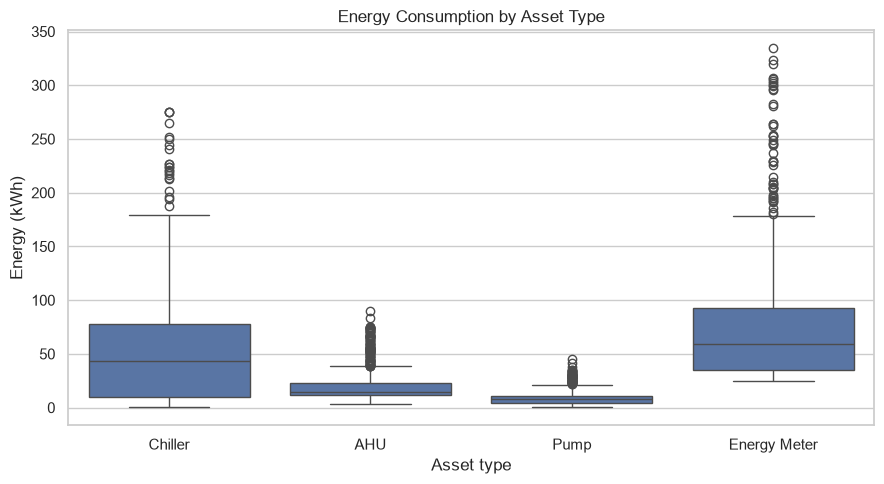

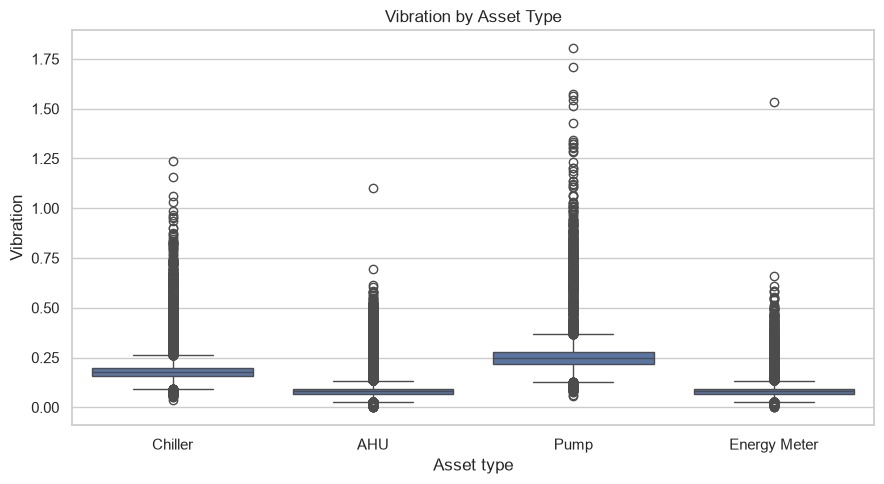

In [10]:
asset_type_summary = (
    eda_df.groupby("asset_type")
    .agg(
        avg_temperature=("temperature", "mean"),
        avg_pressure=("pressure", "mean"),
        avg_vibration=("vibration", "mean"),
        avg_power=("power_consumption", "mean"),
        total_energy=("power_consumption", "sum"),
        fault_rate=("fault_flag", "mean"),
        readings=("asset_id", "size")
    )
    .sort_values("avg_power", ascending=False)
)
display(asset_type_summary)

plt.figure(figsize=(9, 5))
sns.boxplot(data=eda_df, x="asset_type", y="power_consumption")
plt.title("Energy Consumption by Asset Type")
plt.xlabel("Asset type")
plt.ylabel("Energy (kWh)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(data=eda_df, x="asset_type", y="vibration")
plt.title("Vibration by Asset Type")
plt.xlabel("Asset type")
plt.ylabel("Vibration")
plt.tight_layout()
plt.show()

## 7. Equipment Failure Analysis

Identify variables that differ between normal and fault conditions and investigate whether sensor behavior changes before faults. This section provides candidate signals for the later **24-hour failure prediction** task.

**Important:** `fault_flag` is the observed fault indicator. The predictive-maintenance target `failure_next_24h` will be engineered later from future fault events; it is not used as a raw input here.

In [11]:
fault_count = int(eda_df["fault_flag"].sum())
fault_rate = eda_df["fault_flag"].mean() * 100
print(f"Fault-positive readings: {fault_count:,}")
print(f"Fault rate: {fault_rate:.3f}%")

fault_by_type = (
    eda_df.groupby("asset_type")
    .agg(total_readings=("fault_flag", "size"), fault_readings=("fault_flag", "sum"), fault_rate=("fault_flag", "mean"))
)
fault_by_type["fault_rate_percent"] = fault_by_type["fault_rate"] * 100
display(fault_by_type)

fault_comparison = eda_df.groupby("fault_flag")[["temperature", "humidity", "pressure", "vibration", "power_consumption", "occupancy_count"]].agg(["mean", "median"])
display(fault_comparison)

Fault-positive readings: 270
Fault rate: 0.104%


,total_readings,fault_readings,fault_rate,fault_rate_percent
asset_type,,,,
AHU,103680,125,0.001,0.121
Chiller,51840,60,0.001,0.116
Energy Meter,51840,35,0.001,0.068
Pump,51840,50,0.001,0.096


temperature        humidity        pressure        vibration  \
                  mean median     mean median     mean median      mean   
fault_flag                                                                
0               22.513 22.506   51.756 51.549    1.800  1.096     0.135   
1               24.084 24.343   51.971 51.879    1.864  1.073     0.540   

                  power_consumption        occupancy_count         
           median              mean median            mean median  
fault_flag                                                         
0           0.100            29.310 15.055          67.781 34.000  
1           0.493            31.734 15.949          67.874 33.000

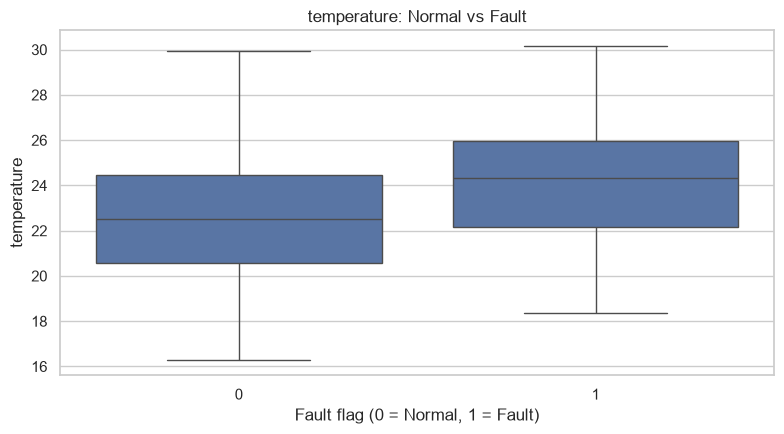

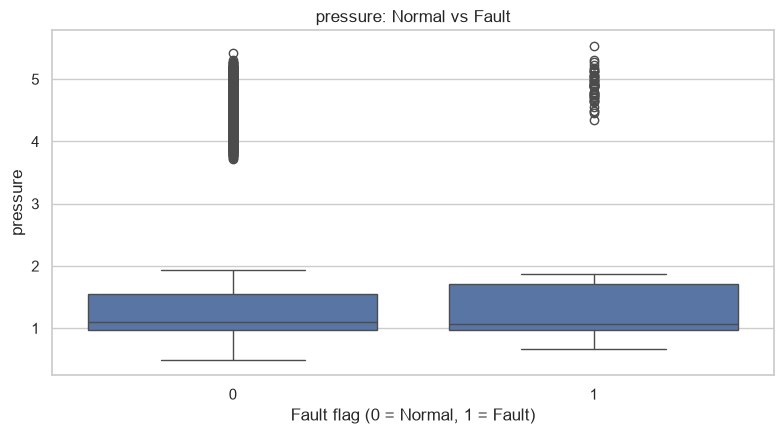

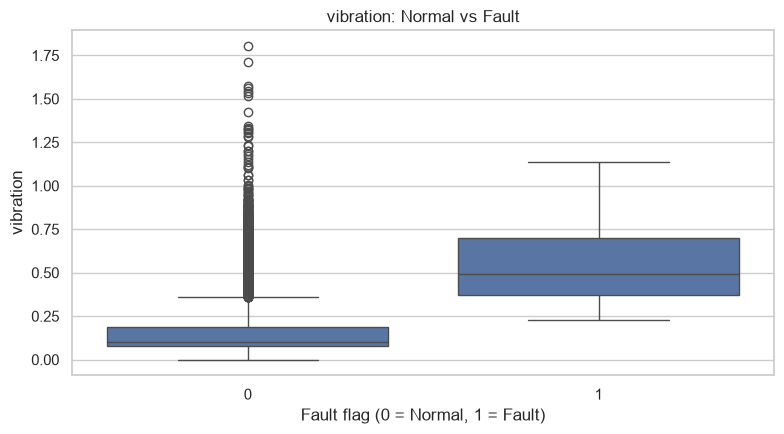

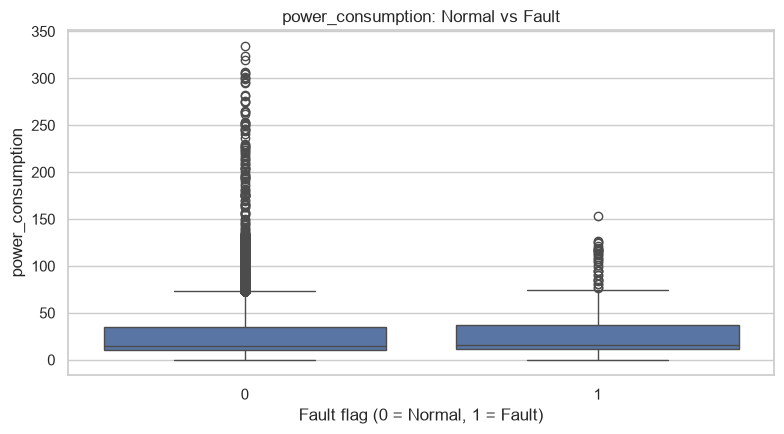

Correlation with fault_flag:


fault_flag          1.000
vibration           0.162
temperature         0.021
power_consumption   0.003
pressure            0.002
humidity            0.001
occupancy_count     0.000
Name: fault_flag, dtype: float64

In [12]:
# Normal vs fault distributions
for col in ["temperature", "pressure", "vibration", "power_consumption"]:
    plt.figure(figsize=(8, 4.5))
    sns.boxplot(data=eda_df, x="fault_flag", y=col)
    plt.title(f"{col}: Normal vs Fault")
    plt.xlabel("Fault flag (0 = Normal, 1 = Fault)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Simple correlations with fault flag — association only, not causation
fault_corr = eda_df[["temperature", "humidity", "pressure", "vibration", "power_consumption", "occupancy_count", "fault_flag"]].corr()["fault_flag"].sort_values(ascending=False)
print("Correlation with fault_flag:")
display(fault_corr)

,asset_type,asset_age_days,fault_rate,avg_vibration,avg_power
asset_id,,,,,
ASSET_001,Chiller,1352,0.002,0.184,43.189
ASSET_002,AHU,1008,0.002,0.083,16.694
ASSET_003,AHU,1408,0.002,0.083,16.977
ASSET_005,Energy Meter,961,0.002,0.084,60.797
ASSET_011,Chiller,599,0.002,0.168,41.988
ASSET_007,AHU,1431,0.002,0.083,16.881
ASSET_013,AHU,2084,0.002,0.083,17.008
ASSET_022,AHU,1517,0.002,0.083,16.987
ASSET_017,AHU,1283,0.002,0.083,16.960


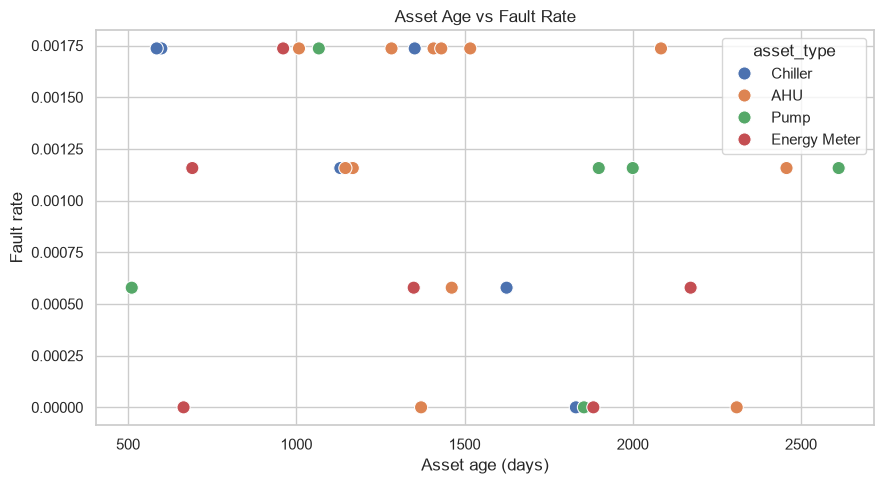

In [13]:
# Asset age
reference_date = eda_df["timestamp"].max()
eda_df["asset_age_days"] = (reference_date - eda_df["installation_date"]).dt.days
asset_health = (
    eda_df.groupby("asset_id")
    .agg(asset_type=("asset_type", "first"), asset_age_days=("asset_age_days", "first"), fault_rate=("fault_flag", "mean"), avg_vibration=("vibration", "mean"), avg_power=("power_consumption", "mean"))
)
display(asset_health.sort_values("fault_rate", ascending=False).head(10))

plt.figure(figsize=(9, 5))
sns.scatterplot(data=asset_health, x="asset_age_days", y="fault_rate", hue="asset_type", s=90)
plt.title("Asset Age vs Fault Rate")
plt.xlabel("Asset age (days)")
plt.ylabel("Fault rate")
plt.tight_layout()
plt.show()

### 7.1 Pre-Fault Behavior

Instead of only comparing fault vs normal readings, examine the telemetry in the **24 hours before a recorded fault**. This is closer to the predictive-maintenance problem and helps identify early degradation signals.

Readings within 24h before a fault: 5112


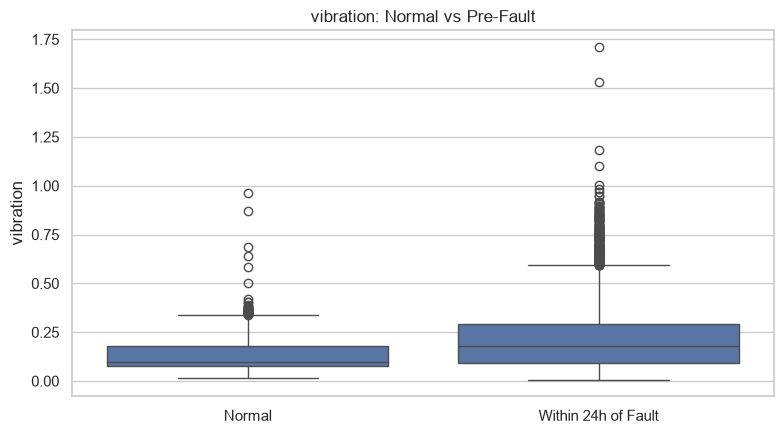

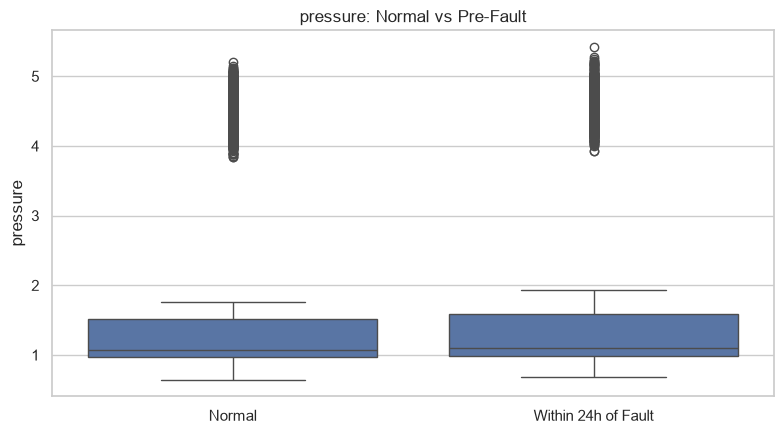

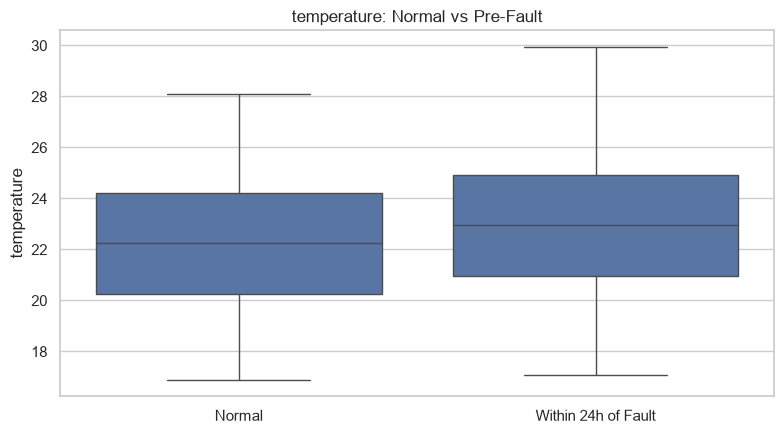

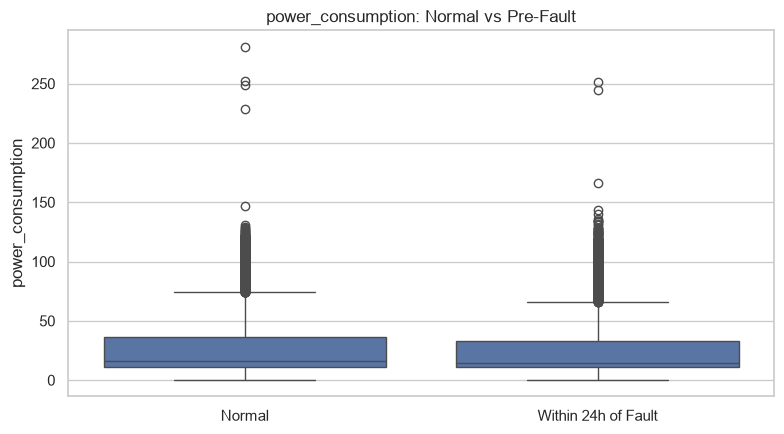

In [14]:
# Find the next fault for each asset using searchsorted
sorted_faults = (
    eda_df.loc[eda_df["fault_flag"] == 1, ["asset_id", "timestamp"]]
    .sort_values(["asset_id", "timestamp"])
)

pre_fault = eda_df.sort_values(["asset_id", "timestamp"]).copy()
pre_fault["next_fault_time"] = pd.NaT

for asset_id, idx in pre_fault.groupby("asset_id").groups.items():
    faults = sorted_faults.loc[sorted_faults["asset_id"] == asset_id, "timestamp"].sort_values().to_numpy(dtype="datetime64[ns]")
    if len(faults) == 0:
        continue
    times = pre_fault.loc[idx, "timestamp"].to_numpy(dtype="datetime64[ns]")
    pos = np.searchsorted(faults, times, side="left")
    valid = pos < len(faults)
    next_times = np.full(len(times), np.datetime64("NaT"), dtype="datetime64[ns]")
    next_times[valid] = faults[pos[valid]]
    pre_fault.loc[idx, "next_fault_time"] = next_times

pre_fault["hours_to_next_fault"] = (pre_fault["next_fault_time"] - pre_fault["timestamp"]).dt.total_seconds() / 3600
pre_fault_24h = pre_fault[(pre_fault["hours_to_next_fault"] > 0) & (pre_fault["hours_to_next_fault"] <= 24)].copy()
print("Readings within 24h before a fault:", len(pre_fault_24h))

# Compare normal observations with pre-fault observations
normal_pool = pre_fault[pre_fault["hours_to_next_fault"].isna()]
normal_sample = normal_pool.sample(min(20000, len(normal_pool)), random_state=42)
pre_sample = pre_fault_24h.sample(min(20000, len(pre_fault_24h)), random_state=42)
normal_sample["condition"] = "Normal"
pre_sample["condition"] = "Within 24h of Fault"
comparison = pd.concat([normal_sample, pre_sample])

for col in ["vibration", "pressure", "temperature", "power_consumption"]:
    plt.figure(figsize=(8, 4.5))
    sns.boxplot(data=comparison, x="condition", y=col)
    plt.title(f"{col}: Normal vs Pre-Fault")
    plt.xlabel("")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### 7.2 Pre-Fault Numerical Comparison

Quantify the difference between the reference normal observations and observations recorded within 24 hours before a fault.

For each health/energy variable, report:
- Mean
- Median
- Percentage change from the normal reference group

This converts the pre-fault boxplots into measurable evidence for the predictive-maintenance task.

In [15]:
# Numerical comparison: Normal vs Within 24h of Fault
prefault_cols = [
    "temperature",
    "pressure",
    "vibration",
    "power_consumption"
]

prefault_summary = (
    comparison.groupby("condition")[prefault_cols]
    .agg(["mean", "median"])
    .T
)

print("Normal vs Pre-Fault: Mean and Median")
display(prefault_summary.round(3))

# Percentage change: Pre-Fault relative to Normal
group_means = comparison.groupby("condition")[prefault_cols].mean()
group_medians = comparison.groupby("condition")[prefault_cols].median()

mean_change = (
    (group_means.loc["Within 24h of Fault"] - group_means.loc["Normal"])
    / group_means.loc["Normal"] * 100
)

median_change = (
    (group_medians.loc["Within 24h of Fault"] - group_medians.loc["Normal"])
    / group_medians.loc["Normal"] * 100
)

prefault_change = pd.DataFrame({
    "mean_change_percent": mean_change,
    "median_change_percent": median_change
})

print("Percentage change: Pre-Fault relative to Normal")
display(prefault_change.round(2))

# Save for the final report
prefault_summary.to_csv(os.path.join(TABLE_DIR, "prefault_mean_median.csv"))
prefault_change.to_csv(os.path.join(TABLE_DIR, "prefault_percentage_change.csv"))

Normal vs Pre-Fault: Mean and Median


condition                 Normal  Within 24h of Fault
temperature       mean    22.248               22.928
                  median  22.250               22.941
pressure          mean     1.701                1.791
                  median   1.072                1.104
vibration         mean     0.127                0.224
                  median   0.095                0.181
power_consumption mean    30.203               28.277
                  median  16.067               14.816

Percentage change: Pre-Fault relative to Normal


,mean_change_percent,median_change_percent
temperature,3.060,3.110
pressure,5.270,2.990
vibration,75.650,90.530
power_consumption,-6.380,-7.790


## 8. Energy Consumption Analysis

Identify factors associated with energy demand, including **occupancy, temperature, operating mode, asset type, building, site, and time**. The goal is to identify drivers that can later support 24-hour energy forecasting and energy optimization.

,mean,median,std,min,max
operating_mode,,,,,
Cooling,42.289,25.796,33.665,2.177,334.276
Heating,31.115,17.823,23.428,2.645,169.278
Idle,14.498,11.041,11.207,0.250,144.647


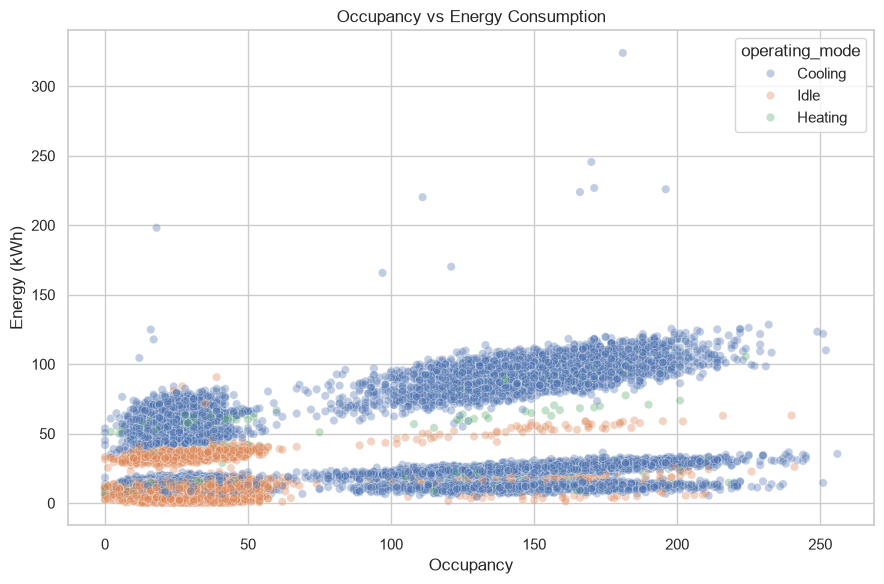

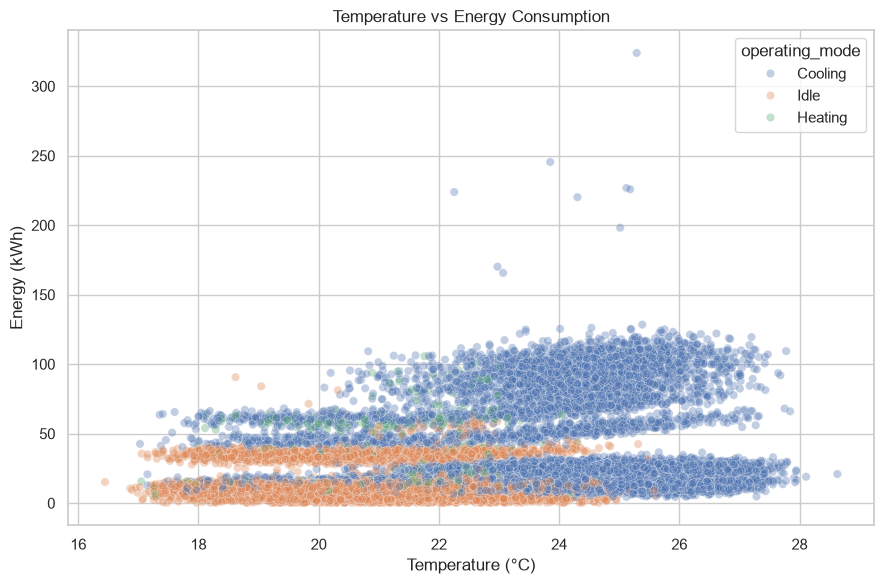

In [16]:
energy_stats = (
    eda_df.groupby("operating_mode")["power_consumption"]
    .agg(["mean", "median", "std", "min", "max"])
)
display(energy_stats)

# Occupancy vs energy
sample = eda_df.sample(min(20000, len(eda_df)), random_state=42)
plt.figure(figsize=(9, 6))
sns.scatterplot(data=sample, x="occupancy_count", y="power_consumption", hue="operating_mode", alpha=0.35)
plt.title("Occupancy vs Energy Consumption")
plt.xlabel("Occupancy")
plt.ylabel("Energy (kWh)")
plt.tight_layout()
plt.show()

# Temperature vs energy
plt.figure(figsize=(9, 6))
sns.scatterplot(data=sample, x="temperature", y="power_consumption", hue="operating_mode", alpha=0.35)
plt.title("Temperature vs Energy Consumption")
plt.xlabel("Temperature (°C)")
plt.ylabel("Energy (kWh)")
plt.tight_layout()
plt.show()

,asset_type,operating_mode,power_consumption
0,AHU,Cooling,21.259
1,AHU,Heating,14.996
2,AHU,Idle,11.989
3,Chiller,Cooling,72.005
4,Chiller,Heating,43.688
5,Chiller,Idle,9.326
6,Energy Meter,Cooling,87.403
7,Energy Meter,Heating,64.303
8,Energy Meter,Idle,35.164
9,Pump,Cooling,10.812


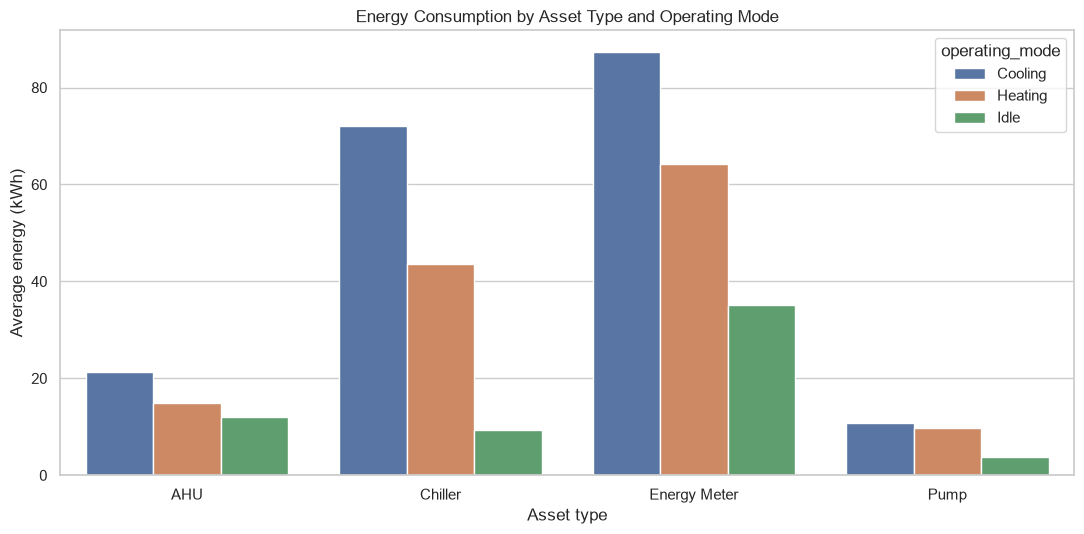

,mean,sum
building_id,,
BLDG_02,29.860,"1,289,968.912"
BLDG_04,29.765,"1,285,851.322"
BLDG_03,29.659,"1,281,258.821"
BLDG_01,29.056,"1,255,209.634"
BLDG_05,28.788,"1,243,660.226"
BLDG_06,28.747,"1,241,877.515"


In [17]:
# Energy by asset type and operating mode
mode_asset_energy = (
    eda_df.groupby(["asset_type", "operating_mode"])["power_consumption"]
    .mean().reset_index()
)
display(mode_asset_energy)

plt.figure(figsize=(11, 5.5))
sns.barplot(data=mode_asset_energy, x="asset_type", y="power_consumption", hue="operating_mode")
plt.title("Energy Consumption by Asset Type and Operating Mode")
plt.xlabel("Asset type")
plt.ylabel("Average energy (kWh)")
plt.tight_layout()
plt.show()

# Building comparison
building_energy = eda_df.groupby("building_id")["power_consumption"].agg(["mean", "sum"]).sort_values("sum", ascending=False)
display(building_energy)

Numeric correlations with energy consumption:


power_consumption    1.000
occupancy_count      0.470
temperature          0.317
humidity            -0.169
vibration           -0.198
pressure            -0.348
Name: power_consumption, dtype: float64

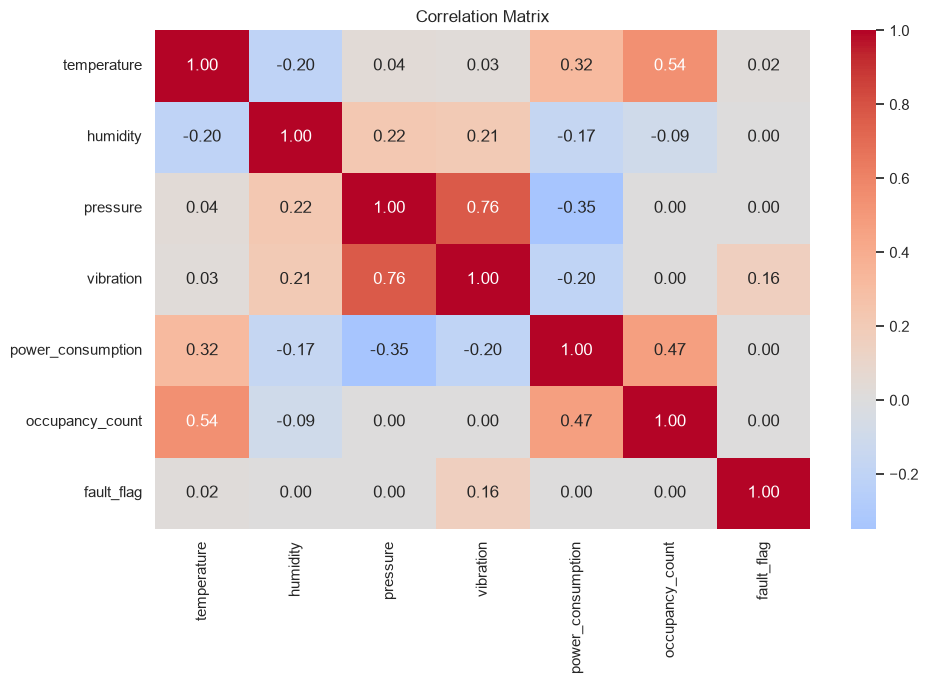

In [18]:
# Numeric relationships with energy
energy_corr = (
    eda_df[["power_consumption", "temperature", "humidity", "pressure", "vibration", "occupancy_count"]]
    .corr()["power_consumption"].sort_values(ascending=False)
)
print("Numeric correlations with energy consumption:")
display(energy_corr)

# Correlation heatmap
corr_cols = ["temperature", "humidity", "pressure", "vibration", "power_consumption", "occupancy_count", "fault_flag"]
plt.figure(figsize=(10, 7))
sns.heatmap(eda_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "correlation_matrix.png"), dpi=150)
plt.show()

## 9. Key Observations and Business Insights

Summarize only findings supported by the computed outputs. Translate the technical patterns into implications for facilities operations, predictive maintenance, and energy management.

In [19]:
# Compact evidence table for the report / presentation
summary = pd.DataFrame({
    "Metric": [
        "Telemetry readings", "Sites", "Buildings", "Assets", "Fault readings",
        "Fault rate (%)", "Missing telemetry cells", "Duplicate telemetry rows",
        "Non-15-minute intervals"
    ],
    "Value": [
        len(telemetry), telemetry["site_id"].nunique(), telemetry["building_id"].nunique(),
        telemetry["asset_id"].nunique(), int(telemetry["fault_flag"].sum()),
        telemetry["fault_flag"].mean() * 100, telemetry.isna().sum().sum(),
        telemetry.duplicated().sum(), (time_diff.dropna() != pd.Timedelta(minutes=15)).sum()
    ]
})
display(summary)

print("\nBusiness interpretation checklist:")
print("1. Data quality: quantify missingness and confirm timestamp/integrity checks before ML.")
print("2. Temporal behavior: use time-of-day and calendar patterns as context for energy forecasting.")
print("3. Asset/site behavior: compare equipment within comparable asset classes and locations.")
print("4. Failure signals: investigate sensor variables that differ before faults; do not treat correlation as causation.")
print("5. Energy drivers: combine occupancy, temperature, operating mode, asset type, building and time.")
print("6. Next tasks: use these findings to guide failure prediction, energy forecasting, anomaly detection and connectivity analysis.")

,Metric,Value
0,Telemetry readings,"259,200.000"
1,Sites,3.000
2,Buildings,6.000
3,Assets,30.000
4,Fault readings,270.000
5,Fault rate (%),0.104
6,Missing telemetry cells,"9,259.000"
7,Duplicate telemetry rows,0.000
8,Non-15-minute intervals,0.000



Business interpretation checklist:
1. Data quality: quantify missingness and confirm timestamp/integrity checks before ML.
2. Temporal behavior: use time-of-day and calendar patterns as context for energy forecasting.
3. Asset/site behavior: compare equipment within comparable asset classes and locations.
4. Failure signals: investigate sensor variables that differ before faults; do not treat correlation as causation.
5. Energy drivers: combine occupancy, temperature, operating mode, asset type, building and time.
6. Next tasks: use these findings to guide failure prediction, energy forecasting, anomaly detection and connectivity analysis.


## 9.1 Evidence-Based Key Insights

### Data Quality & Reliability
- The telemetry contains **259,200 readings** from **30 assets, 6 buildings, and 3 sites** over a 90-day period at 15-minute intervals.
- Missingness is limited to four sensor variables: humidity **1.028%**, temperature **0.984%**, vibration **0.788%**, and pressure **0.772%**.
- No duplicate telemetry rows and no non-15-minute sampling intervals were identified. This provides a reliable temporal foundation for downstream modeling.

### Temporal & Operational Behavior
- The continuous 15-minute time series supports hourly, daily, weekday/weekend, and operating-period analysis.
- Energy demand varies with operating context, so time-of-day and calendar features should be retained for forecasting.

### Asset Behavior Across Sites
- SITE_02 has the highest average energy reading (**29.712**) and total energy, while SITE_03 has the lowest average (**28.768**). The differences are relatively modest, so site-level differences should be interpreted together with building and operating conditions.
- Building-level energy variation is more useful for identifying operational differences than treating the three sites as completely different populations.

### Performance Across Asset Types
- Asset types operate in different physical regimes. Average energy readings are highest for Energy Meters (**62.692**) and Chillers (**42.486**), followed by AHUs (**16.892**) and Pumps (**7.600**).
- Pumps have the highest average vibration (**0.249**) and pressure (**4.502**), while AHUs and Energy Meters have much lower average vibration and pressure. Therefore, equipment-health thresholds should be **asset-type specific**.

### Equipment Failure Signals
- There are **270 fault-positive readings**, corresponding to a fault rate of **0.104%**. This indicates a highly imbalanced predictive-maintenance problem.
- Compared with normal readings, fault readings show higher mean temperature (**24.084 vs 22.513**), vibration (**0.540 vs 0.135**), and power (**31.734 vs 29.310**).
- Vibration has the strongest simple association with the fault flag (**correlation ≈ 0.162**), making it an important candidate feature. This is an association, not proof of causation.
- The pre-fault analysis isolates **5,112 readings within 24 hours before a fault**. The numerical comparison added above quantifies the mean, median, and percentage change for temperature, pressure, vibration, and power.

### Energy Consumption Drivers
- Cooling has the highest average energy demand, followed by Heating and Idle operation.
- Among the numeric variables, occupancy (**≈0.410**) and temperature (**≈0.304**) show the strongest positive associations with energy consumption.
- Energy analysis should combine occupancy, temperature, operating mode, asset type, building, site, and time rather than relying on a single variable or global threshold.

### Business Implications
1. Use sensor-specific missing-value handling and continuous data-quality monitoring.
2. Establish asset-type-specific health baselines for maintenance monitoring.
3. Use vibration and other pre-fault changes as candidate signals for early failure detection.
4. Build energy baselines that account for occupancy, temperature, operating mode, asset type, and time.
5. These EDA findings directly guide Task 2 failure prediction and Task 3 energy forecasting.

In [20]:
# Save important EDA tables
missing_summary.to_csv(os.path.join(TABLE_DIR, "missing_values.csv"))
site_summary.to_csv(os.path.join(TABLE_DIR, "site_summary.csv"))
asset_type_summary.to_csv(os.path.join(TABLE_DIR, "asset_type_summary.csv"))
fault_by_type.to_csv(os.path.join(TABLE_DIR, "fault_by_asset_type.csv"))
energy_stats.to_csv(os.path.join(TABLE_DIR, "energy_by_operating_mode.csv"))
energy_corr.to_csv(os.path.join(TABLE_DIR, "energy_correlations.csv"))
summary.to_csv(os.path.join(TABLE_DIR, "eda_summary.csv"), index=False)
print("EDA tables saved to:", TABLE_DIR)

EDA tables saved to: ../outputs/eda\tables


## EDA Conclusion

The EDA establishes a reliable 15-minute IoT telemetry foundation and identifies the main operational signals relevant to the Nectar challenge. The most important findings are: limited but non-zero sensor missingness; clear differences in behavior across asset types; higher vibration, temperature, and power during fault conditions; a rare and therefore highly imbalanced fault target; and positive associations of occupancy and temperature with energy consumption.

The pre-fault analysis further isolates observations within 24 hours of recorded faults and quantifies the changes in sensor behavior. These findings provide the evidence base for feature engineering and model design in the next tasks.